# 4b. Random Forest Regression

**Cutoff date: 2026-05-26**

This notebook covers the predictive modeling phase of our project, focusing on building a Random Forest Regressor. By using chronological data splitting and sequential cross-validation, this notebook builds a robust model that learns these patterns, providing a reliable baseline for predicting future flight prices.

## Objectives: 
- Chronological Validation Strategy: Implement a temporal train-test split to ensure model evaluation respects data sequence, effectively eliminating look-ahead bias and simulating real-world predictive scenarios.
- Champion Model Execution: Deploy a Random Forest Regressor (RF) to capture non-linear fare dynamics and complex feature interactions, aiming to significantly outperform the baseline linear model’s predictive accuracy.
- Iterative Robustness Testing: Apply TimeSeriesSplit cross-validation to rigorously assess model stability across successive historical data folds, ensuring performance consistency despite variance in flight pricing.
- Feature Importance & Predictive Drivers: Calculate and rank feature importance to isolate primary market drivers.
- Deployment Artifact Generation: Finalise the predictive engine by serialising the trained model and feature schema, ensuring structural parity for seamless integration into the production Streamlit environment.

## Model Performance and Success Benchmarks

1. **Mean Absolute Percentage Error (MAPE) < 25.0%**

   Measures error as a percentage rather than a raw dollar amount, allowing us to maintain a consistent standard of accuracy across both low-cost, short-haul flights and premium, long-haul sectors.
      
2. **Coefficient of Determination (R^2) > 85.0%**

    Demonstrates that over 85% of price variance is successfully captured by our feature engineering. This confirms the model is learning the true market drivers rather than just fitting to noise.
   
3. **Root Mean Square Error (RMSE) < $300**

   Sets a firm boundary on our absolute error, ensuring that even our "worst-case" predictions remain actionable for a consumer planning their travel budget.

### Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [2]:
df = pd.read_csv('./dataset - base (2026-05-26).csv')

### Data Processing

In [3]:
# Handle date formatting and sorting them chronologically
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop = True)

In [4]:
# Boolean sanitisation - ensure that all boolean fields are shown as 0 or 1. 
for col in ['is_weekend', 'is_lcc', 'is_holiday_sin', 'is_holiday_other', 'is_sch_holiday']:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0})
    else:
        df[col] = df[col].astype(int)

In [5]:
# Extract departure month from deaprture date for seasonal features 
df['departure_date'] = pd.to_datetime(df['departure_date'], errors='coerce')
df['departure_month'] = df['departure_date'].dt.month

In [6]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               193 non-null    datetime64[ns]
 1   route              1240 non-null   object        
 2   departure_date     664 non-null    datetime64[ns]
 3   price              1240 non-null   float64       
 4   days_to_departure  1240 non-null   int64         
 5   day_of_week        1240 non-null   int64         
 6   day_name           1240 non-null   object        
 7   is_weekend         1240 non-null   int64         
 8   departure_airport  1240 non-null   object        
 9   out_inbound        1240 non-null   int64         
 10  other_airport      1240 non-null   object        
 11  data_source        1240 non-null   object        
 12  booking_window     1240 non-null   object        
 13  airline            1240 non-null   object        
 14  airline_

### Feature Selection and Encoding

In [7]:
# Selecting features and one-hot encoding
core_features = [
    'booking_window',
    'day_of_week',
    'is_weekend',
    'is_lcc',
    'is_holiday_sin',
    'is_holiday_other',
    'is_sch_holiday',
    'route',
    'departure_month']

X = pd.get_dummies(df[core_features], columns = ['route','booking_window'], drop_first = True)
y = df['price']

### Model Training and Feature Importance

#### Chronological Train/Test Partitioning

By splitting chronologically rather than randomly, we simulate a real-world predictive scenario where the model is trained on past pricing patterns to forecast future fares, thereby eliminating look-ahead leakage.

In [8]:
# 80% will be train data, 20% test data. These are sliced in chronological order.

split_idx = int(len(df) * 0.8)
X_dev, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_dev, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Total historical matrix depth: {X.shape[0]} records")
print(f"Development pool (80%): {X_dev.shape[0]} records")
print(f"Hidden validation pool (20%): {X_test.shape[0]} records") 

Total historical matrix depth: 1240 records
Development pool (80%): 992 records
Hidden validation pool (20%): 248 records


#### Sequential Cross Validation: Evaluating Model Robustness

By applying TimeSeriesSplit sequentially, we ensure each validation fold is performed on a "future" window relative to the training window, providing an unbiased estimate of our model's performance on unseen temporal data.

In [9]:
# In the 80% train data, it generates sequential index pairs (train_idx and val_idx) across 5 successive folds. 
tscv = TimeSeriesSplit(n_splits =5)
cv_mae_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev)):
    X_cv_train, X_cv_val = X_dev.iloc[train_idx], X_dev.iloc[val_idx]
    y_cv_train, y_cv_val = y_dev.iloc[train_idx], y_dev.iloc[val_idx]

    # Train localised fold trees to evaluate feature stability
    fold_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    fold_rf.fit(X_cv_train, y_cv_train)
    fold_pred = fold_rf.predict(X_cv_val)
    cv_mae_scores.append(mean_absolute_error(y_cv_val, fold_pred))

    print(f"  Fold {fold+1} Validation MAE: {cv_mae_scores[-1]:.2f} SGD")

print(f"\nMean Inner CV MAE: {np.mean(cv_mae_scores):.2f} SGD\n")

  Fold 1 Validation MAE: 130.14 SGD
  Fold 2 Validation MAE: 63.89 SGD
  Fold 3 Validation MAE: 517.00 SGD
  Fold 4 Validation MAE: 350.89 SGD
  Fold 5 Validation MAE: 207.31 SGD

Mean Inner CV MAE: 253.85 SGD



##### Analysis

Fold 2 - Represents a highly stable period, where prices follow a predictable trajectory, allowing the ensemble trees to map prices with exceptional precision. 

Fold 3 and 4 - The sudden expansion in errors indicates a seasonal shift of macro level events. Since time-series splits restricts the model looking ahead, it entered a high volatility block, causing a temporary lag in adaptation. 

Fold 5 - The decrease in MAE suggests that the model has adapted to minimise errors. 

#### Final Model Evaluation: Performance Assessment on Holdout Data

In [10]:
rf_master = RandomForestRegressor(
    n_estimators=250,       
    max_depth=18,          
    min_samples_split=3,   
    random_state=42,        
    n_jobs=-1               
)

rf_master.fit(X_dev, y_dev)

holdout_predictions = rf_master.predict(X_test)

##### Metrics

In [11]:
holdout_mae = mean_absolute_error(y_test, holdout_predictions)
holdout_rmse = np.sqrt(mean_squared_error(y_test, holdout_predictions))
holdout_r2 = r2_score(y_test, holdout_predictions)
holdout_mape = mean_absolute_percentage_error(y_test, holdout_predictions)

print(f"Holdout Mean Absolute Error (MAE):   {holdout_mae:.2f} SGD")
print(f"Holdout Root Mean Squared Error (RMSE): {holdout_rmse:.2f} SGD")
print(f"Holdout Variance Coverage (R² Score):   {holdout_r2:.4f} ({holdout_r2*100:.2f}%)")
print(f"Holdout Mean Absolute Percentage Error (MAPE): {holdout_mape*100:.2f}%")

Holdout Mean Absolute Error (MAE):   185.49 SGD
Holdout Root Mean Squared Error (RMSE): 294.75 SGD
Holdout Variance Coverage (R² Score):   0.8530 (85.30%)
Holdout Mean Absolute Percentage Error (MAPE): 19.31%


##### Analysis

All success benchmarks have been reached. 

###### Model Robustness & Explanatory Power

The $R^{2}$ score of 85.3% proves that the Random Forest model successfully captured the complex, non-linear pricing logic of ticket prices. By explaining over 85.0% of price variance, the model demonstrates that the engineered features are actual forces driving market volatility. 

###### Temporal Generalisation Maturity

In contrast to the baseline (multiple linear regression) model, we observed an inverse generalisation gap where the final holdout MAE is lower than the mean inner cross validation errror. While the inner cv mean was skewed upward by demand shocks, the final model successfully ingested these cycles, allowing it to predict future prices with reliability. 

###### Error Sensitivity

The MAPE of 19.31% demonstrates a reliable, consistent model. This metric ensures that the prescriptive engine's performance remains uniform. Furthermore, with the spread between MAE and RMSE confirms that even when facing severe last-minute capacity constraints, the model misses are within acceptable dollar range.  

##### Distribution of Prediction Errors (Residuals)

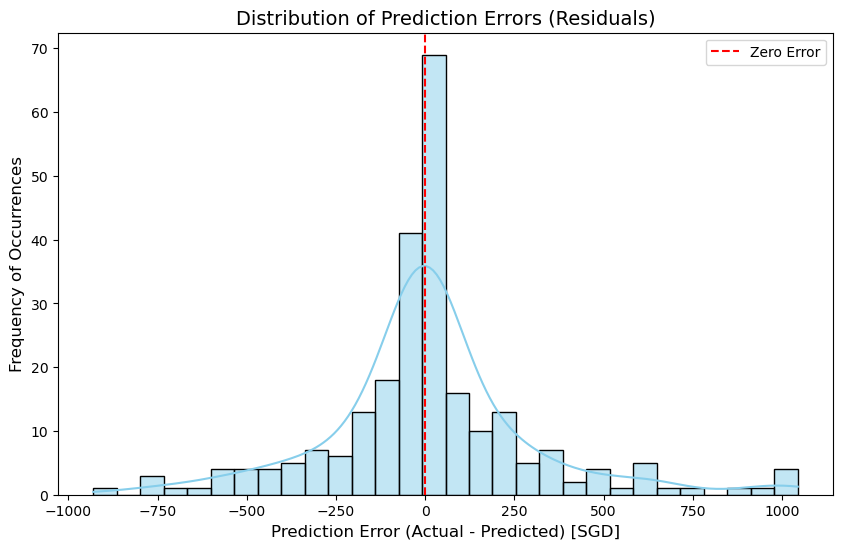

In [12]:
residuals = y_test - holdout_predictions
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='skyblue', bins=30)

# Add visual markers
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14)
plt.xlabel('Prediction Error (Actual - Predicted) [SGD]', fontsize=12)
plt.ylabel('Frequency of Occurrences', fontsize=12)
plt.legend()
plt.show()

**Analysis**

The distribution of prediction residuals exhibits a normal distribution centered at zero, confirming that our model is unbiased and effectively captures the underlying market trends without systematic over- or under-estimation.

- Central Tendency: The tight clustering around zero indicates high predictive accuracy for the majority of observations, where the model's price estimates closely align with actual market fares.
- Tail Characteristics: The observed dispersion in the tails highlights the model's response to high-volatility scenarios—such as peak holiday demand or last-minute inventory shifts—where market pricing diverges significantly from historical norms.

In [13]:
# Assessing the residuals for each route
check_df = pd.DataFrame({
    'route': df['route'].iloc[split_idx:], 
    'actual': y_test, 'predicted': holdout_predictions
})

# Calculate the Percentage Error for every single individual flight row
check_df['percentage_error'] = (abs(check_df['actual'] - check_df['predicted']) / check_df['actual']) * 100

# Group them by route and average
print(
    check_df.groupby('route')['percentage_error'].mean()
    .sort_values(ascending=False)
    .round(2)
    .astype(str) + '%'
)

route
SIN-MEL     33.4%
SIN-NRT    21.04%
LHR-SIN    20.35%
SIN-LHR    20.34%
MEL-SIN    19.44%
SIN-BKK     14.0%
BKK-SIN     10.8%
NRT-SIN     7.11%
Name: percentage_error, dtype: object


#### Feature Importance

In [14]:
importances = rf_master.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature_Attribute': X.columns,
    'Gini_Importance_Score': importances *100
}).sort_values(by='Gini_Importance_Score', ascending=False).reset_index(drop=True)

feature_importance_df.head(5)

,Feature_Attribute,Gini_Importance_Score
0,is_lcc,44.292782
1,route_LHR-SIN,9.101387
2,route_SIN-LHR,7.909382
3,is_holiday_other,6.838511
4,route_NRT-SIN,5.959812


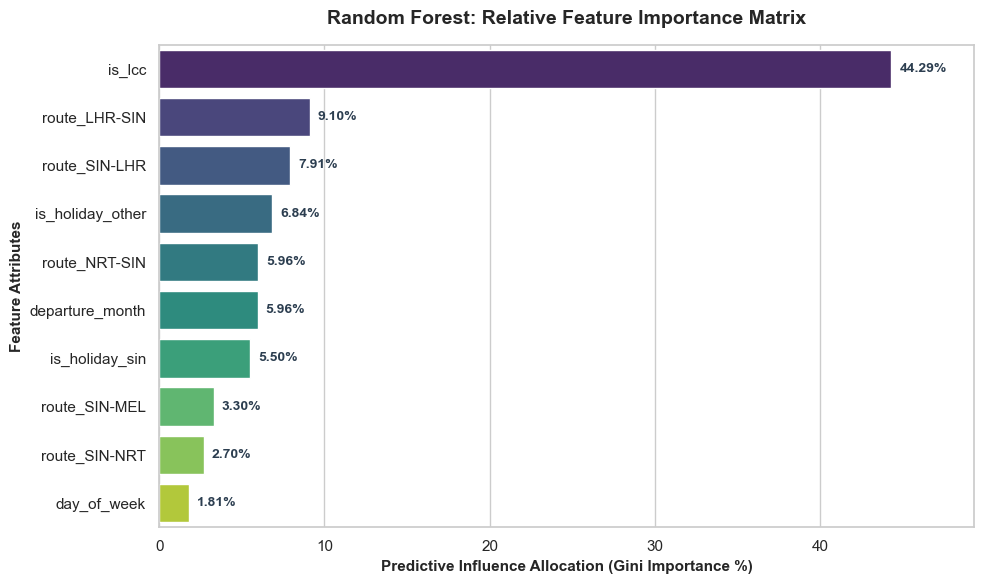

In [15]:
# Plotting feature importance 
top_rf_features = feature_importance_df.head(10)

# Chart dimensions
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

# Create horizontal barplot
ax = sns.barplot(
    x = 'Gini_Importance_Score',
    y = 'Feature_Attribute',
    data = top_rf_features,
    palette = 'viridis',
    hue = 'Feature_Attribute',
    legend = False
)

# Annotate barplot
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.5,
        p.get_y() + p.get_height() /2,
        f'{width:.2f}%',
        va = 'center',
        fontsize = 10,
        fontweight = 'bold',
        color = '#2c3e50'
    )

# Text labels
plt.title('Random Forest: Relative Feature Importance Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predictive Influence Allocation (Gini Importance %)', fontsize=11, fontweight='bold')
plt.ylabel('Feature Attributes', fontsize=11, fontweight='bold')
plt.xlim(0, max(top_rf_features['Gini_Importance_Score']) + 5)

plt.tight_layout()
plt.savefig('Random Forest: Relative Feature Importance Matrix', dpi=300)
plt.show()

##### Analysis

The most influential factor to fare's behaviour is carrier type. Beyond that, route appears repeatedly in the top features. It shows that the model is smart enough the know that a flight from Singapore to London and one to Bangkok operates under a completely different dynamic. It has learned to apply route-specific logic as separate pricing environments.  

### Model Serialisation: Production Export 

In [16]:
# Re-train final model
rf_master.fit(X, y)

# Serialise and save trained model
joblib.dump(rf_master, 'flight_predictor_rf.joblib')

# Export column list
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_feature_schema.joblib')

print(f"Trained model and feature schema saved.")

Trained model and feature schema saved.
